<a href="https://colab.research.google.com/github/Paramita15101985/Paramita15101985/blob/main/CV_assignment2_group18_01_pdf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV_assignment2_group18_01
# EuroSAT Scene Classification using Handcrafted Features

In [ ]:
# Step 1: Import Required Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import local_binary_pattern, hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, f1_score
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Step 2: Mount Google Drive and Set Dataset Path
from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/EuroSAT_sample'  # Ensure this path matches your Drive structure
classes = sorted(os.listdir(dataset_path))
print("Selected Classes:", classes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Selected Classes: ['Forest', 'Highway', 'Industrial', 'Residental', 'River']


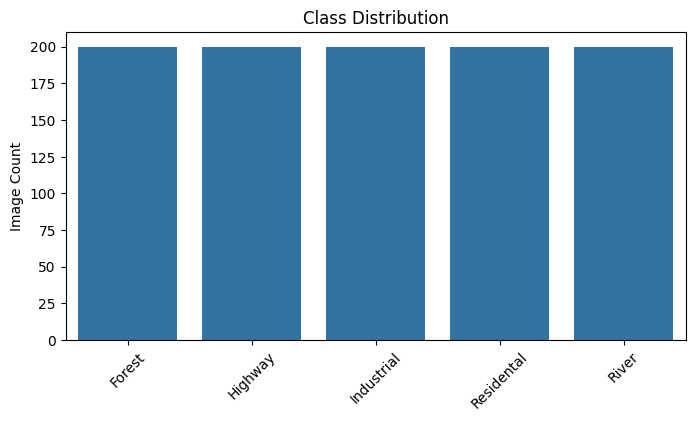

In [ ]:
# Step 3: Visualize Dataset Distribution
class_counts = {cls: len(os.listdir(os.path.join(dataset_path, cls))) for cls in classes}
plt.figure(figsize=(8,4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Class Distribution")
plt.ylabel("Image Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Step 4: Data Preparation (Resize, Grayscale, Histogram Equalization)
IMG_SIZE = 128
X = []
y = []

for label, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    for img_file in tqdm(os.listdir(class_path), desc=f"Processing {cls}"):
        img_path = os.path.join(class_path, img_file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        equalized = cv2.equalizeHist(gray)
        X.append(equalized)
        y.append(label)

X = np.array(X)
y = np.array(y)

# Split the dataset (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


Processing River: 100%|██████████| 200/200 [00:02<00:00, 70.09it/s] 


In [ ]:
# Step 5: Feature Engineering (HOG + LBP + Edge Histogram)
def extract_features(images, use_hog=True, use_lbp=True, use_edge=True):
    features = []
    for img in tqdm(images, desc="Extracting Features"):
        feat_vector = []
        if use_lbp:
            lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
            hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 10), range=(0, 9))
            hist = hist.astype("float") / (hist.sum() + 1e-6)
            feat_vector.extend(hist)
        if use_hog:
            hog_feat = hog(img, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
            feat_vector.extend(hog_feat)
        if use_edge:
            edges = cv2.Canny(img, 100, 200)
            edge_hist, _ = np.histogram(edges.ravel(), bins=16, range=(0, 256))
            edge_hist = edge_hist.astype("float") / (edge_hist.sum() + 1e-6)
            feat_vector.extend(edge_hist)
        features.append(feat_vector)
    return np.array(features)

X_train_feat = extract_features(X_train)
X_test_feat = extract_features(X_test)

# Normalize
scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)


Extracting Features: 100%|██████████| 200/200 [00:02<00:00, 86.85it/s]


In [ ]:
# Step 6: Model Training (SVM and Random Forest)
models = {
    "SVM": SVC(kernel='linear', random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_feat, y_train)
    y_pred = model.predict(X_test_feat)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {"Accuracy": acc, "F1 Score": f1}
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))


SVM Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        40
           1       0.76      0.72      0.74        40
           2       0.76      0.80      0.78        40
           3       0.88      0.93      0.90        40
           4       0.84      0.68      0.75        40

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200


RandomForest Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92        40
           1       0.70      0.65      0.68        40
           2       0.83      0.88      0.85        40
           3       0.91      1.00      0.95        40
           4       0.85      0.72      0.78        40

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg

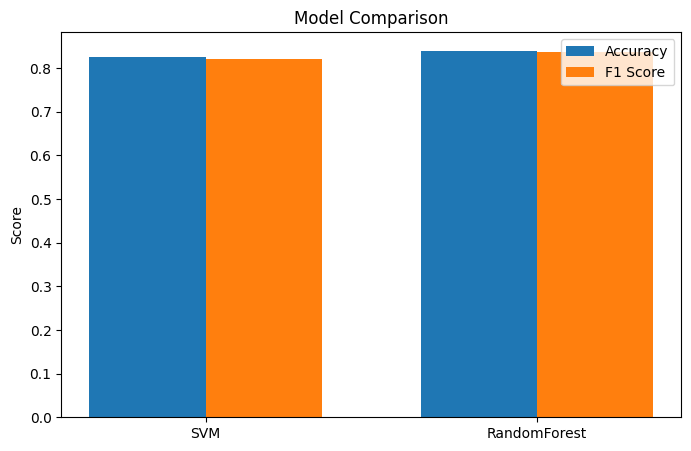

In [ ]:
# Step 7: Visualize Model Performance
labels = list(results.keys())
accs = [results[k]['Accuracy'] for k in labels]
f1s = [results[k]['F1 Score'] for k in labels]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(8,5))
plt.bar(x - width/2, accs, width, label='Accuracy')
plt.bar(x + width/2, f1s, width, label='F1 Score')
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.show()

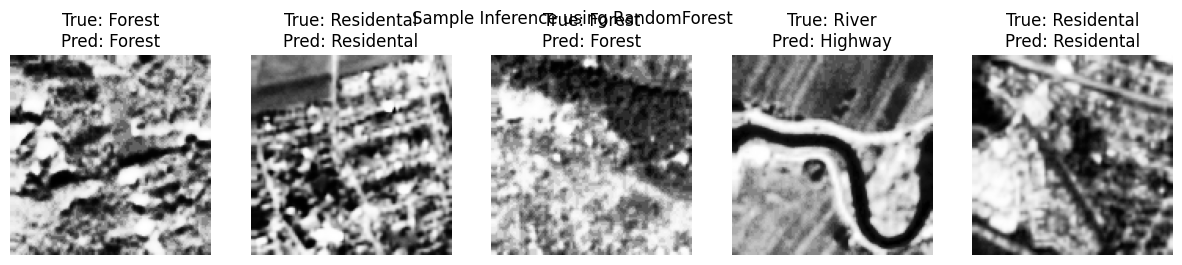

In [ ]:
# Step 8: Model Inference (Sample Predictions)
sample_idxs = np.random.choice(len(X_test), 5, replace=False)
plt.figure(figsize=(15,3))
for i, idx in enumerate(sample_idxs):
    img = X_test[idx]
    true_lbl = classes[y_test[idx]]
    pred_lbl = classes[models['RandomForest'].predict([X_test_feat[idx]])[0]]
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_lbl}\nPred: {pred_lbl}")
    plt.axis('off')
plt.suptitle("Sample Inference using RandomForest")
plt.show()

In [ ]:
# Step 9: Individual Contribution
print("\nIndividual Contributions:")
print("Paramita Pal: Dataset selection, feature engineering, model building, evaluation, and documentation")



Individual Contributions:
Paramita Pal: Dataset selection, feature engineering, model building, evaluation, and documentation
